# Four-model interpretability

Post-hoc interpretability for the four Kitaev-chain models. Everything here
reads artefacts a completed `four_model_comparison.py` run already produced,
so it never touches training and cannot perturb the matched comparison.

The numerics and plots live in `kitaev.xai`; this notebook is the
interactive front end. The big ablation stays a script.

**Prerequisite.** Run `python experiments/four_model_comparison.py` first.
It writes everything into one session directory under `results/logs/`, a
checkpoint per (model, seed) under `<session>/checkpoints/` and the per-run
table at `<session>/four_model_comparison.csv`.

Sections:

1. Transparency axis, accuracy against structure internalised.
2. Residual conditioning, the spectral-gap mechanism behind the
   trivial-phase accuracy gap.
3. Cross-seed dispersion, where each model is under-determined.
4. Residual difficulty map, where each trained model still breaks the
   physics.


## Setup

The comparison script is a sibling module under `experiments/`, so put that
directory on the path before importing it.

In [1]:
%matplotlib inline
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Walk up from ``start`` until the experiments package is visible.

    Robust to the kernel's working directory being the notebook folder,
    the repo root, or anywhere between.
    """
    for candidate in (start, *start.parents):
        if (candidate / "experiments" / "four_model_comparison.py").exists():
            return candidate
    raise RuntimeError(f"could not locate the repo root starting from {start}")


REPO = _find_repo_root(Path.cwd())
if str(REPO / "experiments") not in sys.path:
    sys.path.insert(0, str(REPO / "experiments"))

In [2]:
import matplotlib.pyplot as plt
from four_model_comparison import DELTA, MODEL_ORDER, MU_GRID, RECIPES, N, T

from kitaev.analytical import KitaevChainHamiltonian
from kitaev.xai import (
    KITAEV_PROFILES,
    XaiAnalysis,
    load_seed_checkpoints,
    plot_conditioning,
    plot_residual_field,
    plot_seed_dispersion,
    plot_transparency_axis,
    psi_only,
    read_comparison_errors,
    save_xai_report,
    shared_dispersion_ylim,
    sweep_conditioning,
    sweep_residual_field,
    sweep_seed_dispersion,
)

In [3]:
# --- configuration ------------------------------------------------------
# By default, take the most recent comparison session and the default CSV.
_sessions = sorted((REPO / "results" / "logs").glob("*four-model-comparison"))
RUN_DIR = _sessions[-1] if _sessions else None
CSV_PATH = RUN_DIR / "four_model_comparison.csv"  # co-located with the run
DEVICE = "cpu"
MODELS = list(MODEL_ORDER)

assert RUN_DIR is not None, "no four-model-comparison session under results/logs"
print("run dir :", RUN_DIR)
print("csv     :", CSV_PATH)
print("models  :", MODELS)

hamiltonian = KitaevChainHamiltonian(n_sites=N, hopping=T, pairing=DELTA)

run dir : /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_canonical_four-model-comparison
csv     : /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_canonical_four-model-comparison/four_model_comparison.csv
models  : ['semi_supervised', 'nambu_baseline', 'structural_nambu', 'chiral']


## The comparison run at a glance

Load the per-run CSV the comparison wrote into this session directory. The
first table is every `(model, seed)` row as-is; the second is the per-model
mean over seeds for the headline metrics, alongside the provenance flags
(`completed`, `converged`) that say whether each run finished its budget
and had settled by the end.

In [4]:
import pandas as pd
from IPython.display import display

runs_df = pd.read_csv(CSV_PATH)
runs_df = runs_df.set_index(["model", "seed"]).sort_index()
display(runs_df)

_headline = [
    "e_mae_trivial",
    "e_mae_topological",
    "subspace_infidelity_mean",
    "edge_mae",
    "var_tail_decades",
    "infidelity_tail_decades",
]
summary_df = (
    runs_df.groupby("model")
    .agg(
        seeds=("wall_seconds", "size"),
        completed=("completed", "sum"),
        converged=("converged", "sum"),
        **{col: (col, "mean") for col in _headline},
    )
    .reindex([m for m in MODELS if m in runs_df.index.get_level_values("model")])
)
display(summary_df)

e_mae_full  e_mae_topological  e_mae_trivial  \
model            seed                                                   
chiral           0     3.056965e-06       5.195265e-06   9.186652e-07   
                 1     6.383271e-06       1.169480e-05   1.071746e-06   
                 2     5.017446e-08       7.494274e-09   9.285464e-08   
                 3     1.719478e-06       2.893648e-06   5.453075e-07   
                 4     1.978885e-07       1.695109e-07   2.262660e-07   
nambu_baseline   0     3.268417e-05       5.507961e-05   1.028873e-05   
                 1     1.022037e-04       1.085526e-04   9.585474e-05   
                 2     1.860819e-05       3.360994e-05   3.606434e-06   
                 3     3.591481e-06       6.478158e-06   7.048046e-07   
                 4     6.325381e-06       1.203530e-05   6.154597e-07   
semi_supervised  0     1.402208e-04       2.558778e-04   2.456382e-05   
                 1     7.685514e-05       1.332896e-04   2.042072e-05   
                 2     1.212297e-04       2.155191e-04   2.694030e-05   
                 3     1.236588e-04       2.267938e-04   2.052379e-05   
                 4     1.269250e-04       2.294024e-04   2.444761e-05   
structural_nambu 0     1.867157e-05       3.542209e-05   1.921053e-06   
                 1     5.889998e-06       1.046212e-05   1.317880e-06   
                 2     3.526604e-05       5.853650e-05   1.199558e-05   
                 3     3.501409e-06       6.884252e-06   1.185657e-07   
                 4     3.595476e-06       7.083377e-06   1.075746e-07   

                       subspace_infidelity_mean  subspace_infidelity_max  \
model            seed                                                      
chiral           0                 8.569173e-06             2.808045e-04   
                 1                 2.080194e-05             2.092537e-04   
                 2                -9.587802e-09             1.045135e-07   
                 3                 4.538299e-06             9.613971e-05   
                 4                 7.283534e-07             6.593785e-06   
nambu_baseline   0                 7.229053e-05             1.993063e-03   
                 1                 3.109692e-04             4.940140e-02   
                 2                 2.638192e-05             2.249653e-04   
                 3                 4.889850e-06             1.006212e-04   
                 4                 7.897507e-06             2.657427e-04   
semi_supervised  0                 4.478775e-04             1.012666e-02   
                 1                 2.129888e-04             4.188861e-03   
                 2                 2.707751e-04             6.653712e-03   
                 3                 2.738748e-04             4.103750e-03   
                 4                 3.600811e-04             6.748650e-03   
structural_nambu 0                 7.350025e-06             1.167426e-04   
                 1                 4.390981e-06             7.701983e-05   
                 2                 3.500367e-05             2.817217e-03   
                 3                 1.966575e-07             2.279120e-06   
                 4                 1.042332e-07             9.250866e-07   

                       edge_mae  pair_density_mae_topo  raw_density_mae_topo  \
model            seed                                                          
chiral           0     0.000368               0.000111              0.000228   
                 1     0.000738               0.000225              0.000319   
                 2     0.000011               0.000003              0.000018   
                 3     0.000365               0.000105              0.000151   
                 4     0.000090               0.000023              0.000096   
nambu_baseline   0     0.000599               0.000730              0.028219   
                 1     0.000976               0.000838              0.025554   
                 2     0.

,seeds,completed,converged,e_mae_trivial,e_mae_topological,subspace_infidelity_mean,edge_mae,var_tail_decades,infidelity_tail_decades
model,,,,,,,,,
semi_supervised,5,5,4,2.337925e-05,0.000212,0.000313,0.002271,0.1232,0.1680
nambu_baseline,5,5,0,2.221403e-05,0.000043,0.000084,0.000478,0.4542,0.6492
structural_nambu,5,5,0,3.092130e-06,0.000024,0.000009,0.000154,0.6884,1.2068
chiral,5,5,0,5.709679e-07,0.000004,0.000007,0.000314,0.9070,0.5110


## 1. Transparency axis

`InternalisationProfile` records, per model, the properties guaranteed by
construction versus only penalised, the number of loss terms, and the
number of tunable weights. Plotted against the energy MAE from the
comparison CSV, the four-model progression reads as a measured trade-off
between how much the network is asked to learn and how accurate it is.

The counts are a summary, not a metric with a unit; they are only
comparable within this family of models on this problem.

semi_supervised    structural=2  loss_workload=5  trivial MAE=2.34e-05
nambu_baseline     structural=1  loss_workload=6  trivial MAE=2.22e-05
structural_nambu   structural=2  loss_workload=2  trivial MAE=3.09e-06
chiral             structural=5  loss_workload=2  trivial MAE=5.71e-07


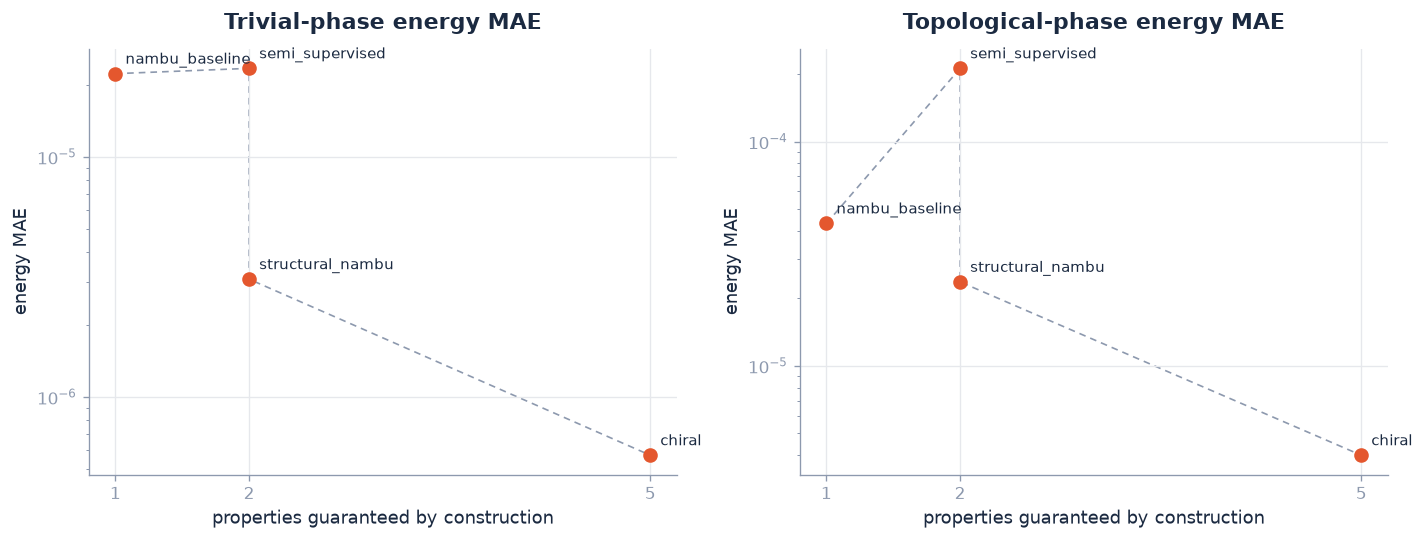

In [5]:
errors = read_comparison_errors(CSV_PATH)
usable = [m for m in MODELS if m in KITAEV_PROFILES and m in errors]
profiles = [KITAEV_PROFILES[m] for m in usable]

for p in profiles:
    print(
        f"{p.name:<18} structural={p.n_structural}  "
        f"loss_workload={p.loss_workload}  "
        f"trivial MAE={errors[p.name]['trivial']:.2e}"
    )

plot_transparency_axis(profiles, {m: errors[m] for m in usable})
plt.show()

## 2. Residual conditioning

The label-free losses pin the solution through a residual whose small
singular values are physical spectral gaps. At fixed `mu` the eigen-residual
is linear in the state, so its Jacobian is the residual operator itself and
its spectrum is exact diagonalisation, no trained model involved.

- **nambu**: `H(mu) - E I`, singular values `|E_k - E|` over the `2N`
  spectrum.
- **chiral**: gaps `|sigma_k - sigma_1|` between the singular values of the
  `N x N` block `h(mu)`.

`sigma_min` is the gap the loss relies on. In the topological phase the
Nambu `sigma_min` collapses onto the exponentially small Majorana
splitting, while the chiral gap stays of order `t`. That contrast is the
mechanism behind the trivial-phase accuracy gap, and it holds as a basis
property with no network in sight.

nambu   sigma_min(mu~0) = 4.423e-05   max condition number = 8.885e+06
chiral  sigma_min(mu~0) = 1.028e+00   max condition number = 4.965e+01


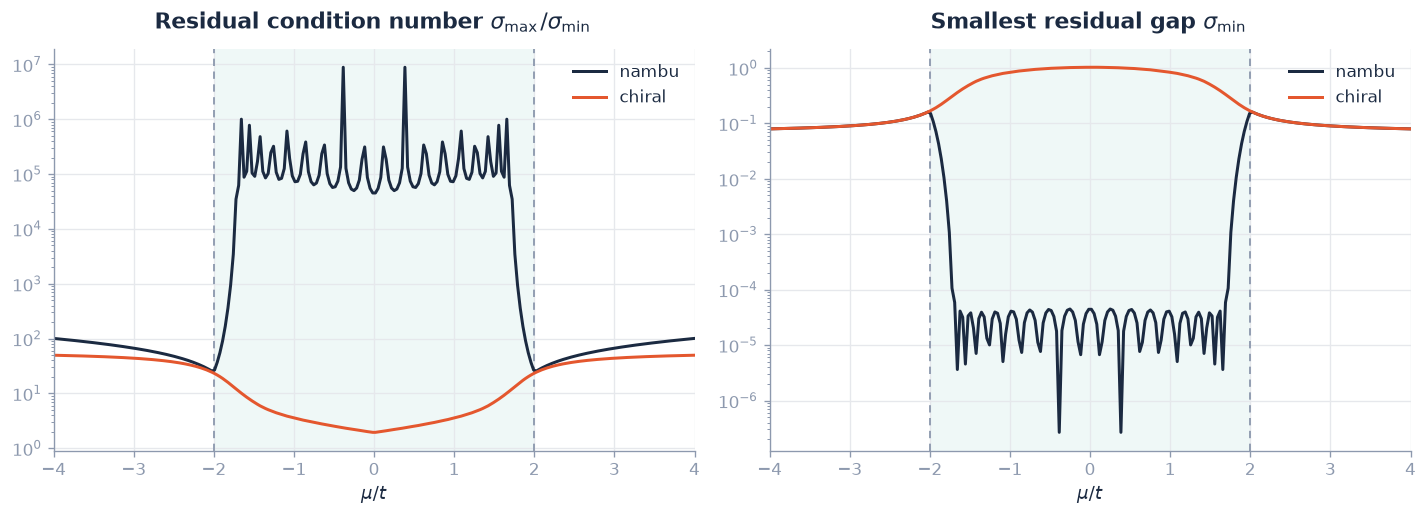

In [6]:
conditioning = {
    basis: sweep_conditioning(
        basis=basis, n_sites=N, hopping=T, pairing=DELTA, mu_grid=MU_GRID
    )
    for basis in ("nambu", "chiral")
}

for basis, sweep in conditioning.items():
    mid = len(sweep.mu) // 2  # near mu = 0
    print(
        f"{basis:<7} sigma_min(mu~0) = {sweep.sigma_min[mid]:.3e}   "
        f"max condition number = {sweep.condition_number.max():.3e}"
    )

plot_conditioning(list(conditioning.values()), hopping=T)
plt.show()

## 3. Cross-seed dispersion

Where the objective is flat over a subspace of solutions, the particular
solution a run lands on is set by the seed. Running each model over its
seeds and measuring how far the output moves maps where its predictions are
under-determined.

The observables are gauge invariant, so no alignment is needed. The
eigenvector is compared through its per-site probability density, which is
sign invariant and is the natural quantity to watch rotate around the
degenerate manifold. Expect a spike inside `|mu| < 2t` for the Nambu-basis
models and a flat curve for the chiral model.

The four panels share one log y-axis (`shared_dispersion_ylim`), because
the point of the section is the relative magnitude of the spread. On that
shared scale the chiral panel should read as a low flat line.

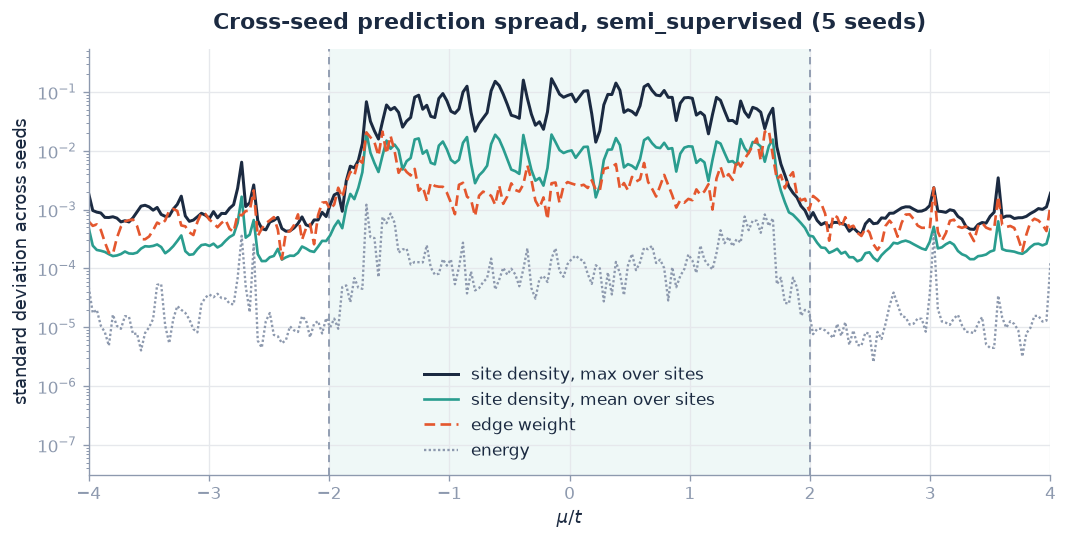

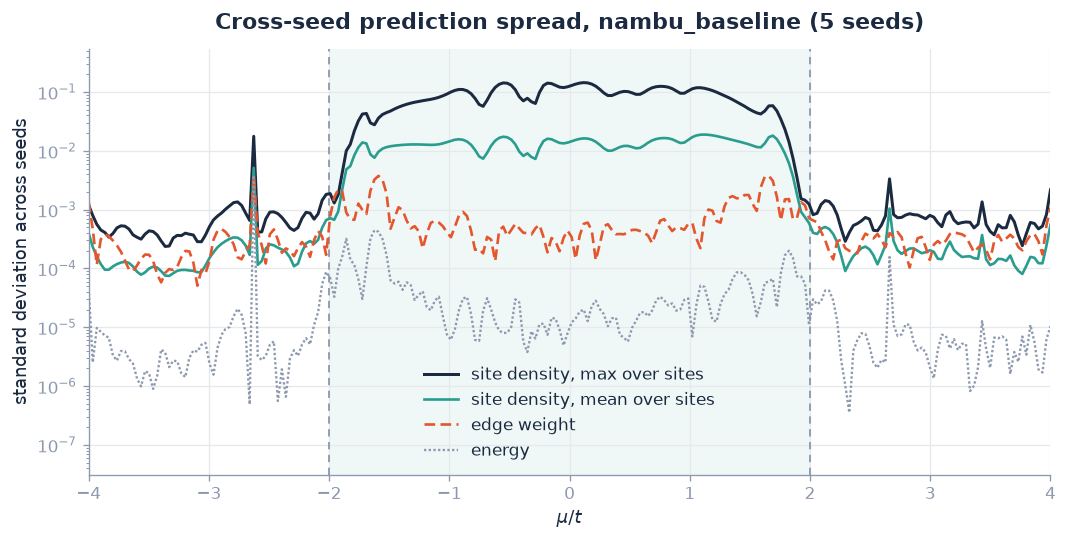

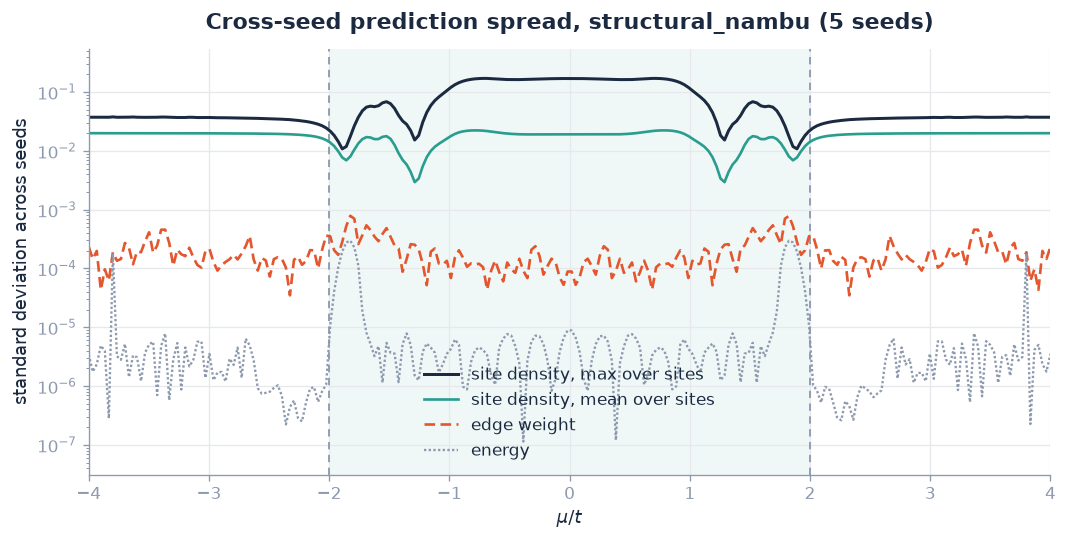

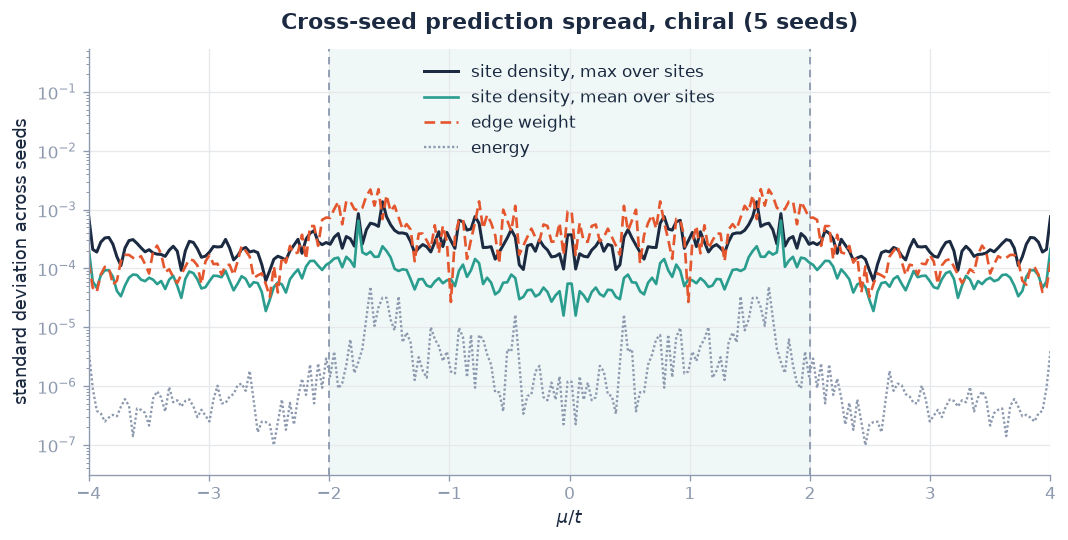

In [7]:
dispersion = {}
for model_name in MODELS:
    recipe = RECIPES[model_name]
    seed_models = load_seed_checkpoints(
        recipe.build_model, RUN_DIR / "checkpoints" / model_name, device=DEVICE
    )
    if len(seed_models) < 2:
        print(f"skip {model_name}: {len(seed_models)} checkpoint(s), need >= 2")
        continue
    adapters = [recipe.build_adapt(m).to(DEVICE) for m in seed_models]
    dispersion[model_name] = sweep_seed_dispersion(
        adapters, hamiltonian, MU_GRID, device=DEVICE
    )

# One shared log axis across models: this section is a magnitude
# comparison, and auto-scaled panels would hide it.
dispersion_ylim = shared_dispersion_ylim(dispersion.values())
for model_name, disp in dispersion.items():
    plot_seed_dispersion(
        disp,
        hopping=T,
        model_label=model_name,
        ylim=dispersion_ylim,
    )
    plt.show()

## 4. Residual difficulty map

The training residual kept per `mu` rather than averaged is a map of where
a trained model still violates the physics. This is what a self-adaptive
weighting scheme would surface, obtained without changing the training
loop.

The particular solution a run lands on is partly set by the seed,
especially in the topological phase, so the map is taken over every seed
and shown as a median line with a band spanning the full inter-seed range,
the same treatment the dispersion section gives these models.

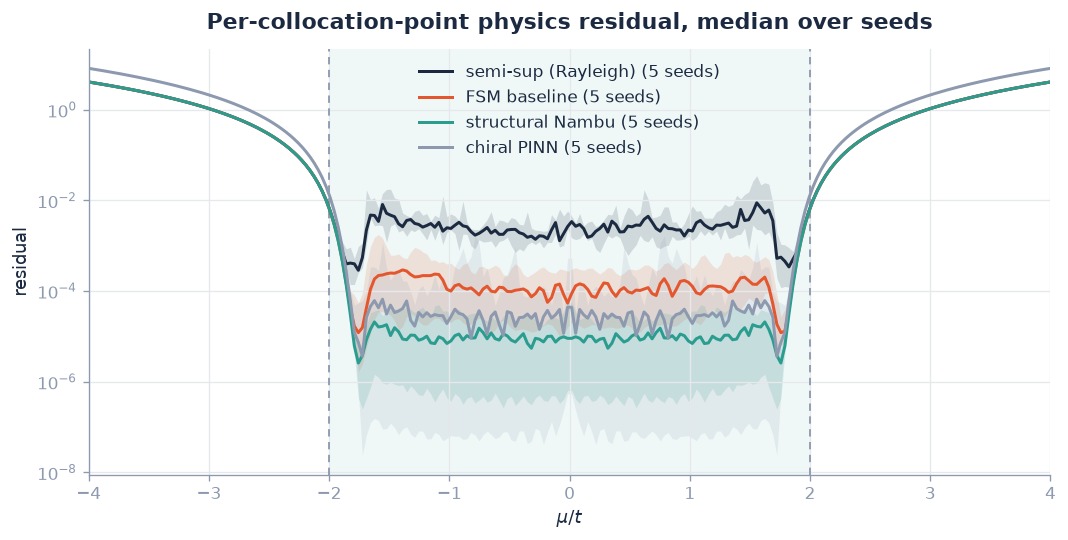

In [8]:
residual_fields = {}
for model_name in MODELS:
    recipe = RECIPES[model_name]
    seed_models = load_seed_checkpoints(
        recipe.build_model, RUN_DIR / "checkpoints" / model_name, device=DEVICE
    )
    if not seed_models:
        print(f"skip {model_name}: no checkpoints")
        continue
    if recipe.basis == "chiral":
        models = seed_models
    else:
        models = [psi_only(m, device=DEVICE) for m in seed_models]
    residual_fields[model_name] = sweep_residual_field(
        models,
        basis=recipe.basis,
        label=recipe.plot_label,
        n_sites=N,
        hopping=T,
        pairing=DELTA,
        mu_grid=MU_GRID,
        device=DEVICE,
    )

plot_residual_field(list(residual_fields.values()), hopping=T)
plt.show()

## 5. Save the full set

Bundle everything into an `XaiAnalysis` and write the figures next to the
comparison run for the write-up.

In [9]:
analysis = XaiAnalysis(
    profiles=profiles,
    errors={m: errors[m] for m in usable},
    dispersion=dispersion,
    conditioning=conditioning,
    residual_fields=residual_fields,
)

paths = save_xai_report(analysis, RUN_DIR / "xai", hopping=T)
for name, path in paths.items():
    print(f"{name:<26} {path}")

transparency_axis          /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_canonical_four-model-comparison/xai/transparency_axis.png
conditioning               /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_canonical_four-model-comparison/xai/conditioning.png
residual_field             /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_canonical_four-model-comparison/xai/residual_field.png
dispersion_semi_supervised /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_canonical_four-model-comparison/xai/dispersion_semi_supervised.png
dispersion_nambu_baseline  /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_canonical_four-model-comparison/xai/dispersion_nambu_baseline.png
dispersion_structural_nambu /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_canonical_four-model-comparison/xai/dispersion_structural_nambu.png
dispersion_chiral          /Users/dev/Projects/pinn-1d-kitaev-chain/results/logs/20260830_ca